Construction of ESG scores

TF/IDF as main measure, mean TF/IDF score as very good variable

Work done on E/G primary indicator words

How should S be introduced? It can't be used to differentiate. But a consistently higher ESG score indicates social stewardship, which can be both E or G. So therefore if a company does well in year N, Year N+1 gets a slight positive bonus, and vice versa, because a decrease is a failure of stewardship

Social does deserve a smaller weighting however, because when viewed relatively, firms have very similar social discourse intensity, but by industry there are slight differentiations.

Normalized search volume for that year is another variable. A high environmental discourse score in a year with high environmental attention could be optics or genuine concern. Nevertheless, it should be a positive variable.



In [4]:
import polars as pl

GOV_FILE = "./governance_time_series_01_01_2015_to_31_12_2024.csv"

# Load CSV
g = pl.read_csv(GOV_FILE)

# Get first column name (Google Trends usually calls it "Week" or "Day")
date_col = g.columns[0]

# Parse date column properly
g = g.with_columns(
    pl.col(date_col)
      .str.strptime(pl.Date, strict=False)
      .alias("date")
)

# Identify keyword columns (everything except date column)
kw_cols = [c for c in g.columns if c not in [date_col, "date"]]

# Ensure numeric
g = g.with_columns([pl.col(c).cast(pl.Float64) for c in kw_cols])

# Add year
g = g.with_columns(
    pl.col("date").dt.year().alias("year")
)

# Annual mean per keyword
g_year_kw = (
    g.group_by("year")
    .agg([pl.mean(c).alias(c) for c in kw_cols])
    .sort("year")
)

# Collapse all governance keywords into one pillar mean
g_year = (
    g_year_kw
    .with_columns(
        pl.mean_horizontal(kw_cols).alias("G_mean")
    )
    .select(["year", "G_mean"])
)

print(g_year)

shape: (10, 2)
┌──────┬───────────┐
│ year ┆ G_mean    │
│ ---  ┆ ---       │
│ i32  ┆ f64       │
╞══════╪═══════════╡
│ 2015 ┆ 14.854167 │
│ 2016 ┆ 14.177083 │
│ 2017 ┆ 13.010417 │
│ 2018 ┆ 12.333333 │
│ 2019 ┆ 11.5      │
│ 2020 ┆ 10.34375  │
│ 2021 ┆ 10.114583 │
│ 2022 ┆ 13.052083 │
│ 2023 ┆ 12.958333 │
│ 2024 ┆ 14.635417 │
└──────┴───────────┘


In [6]:
import polars as pl

ENV_FILE = "./environmental_time_series_01_01_2015_to_31_12_2024_rounded.csv"

# Load CSV
e = pl.read_csv(ENV_FILE)

# First column is the date column (likely "Month")
date_col = e.columns[0]

# Parse date
e = e.with_columns(
    pl.col(date_col)
      .str.strptime(pl.Date, strict=False)
      .alias("date")
)

# Term columns (everything except the raw date column + parsed date)
term_cols = [c for c in e.columns if c not in [date_col, "date"]]

# Ensure numeric
e = e.with_columns([pl.col(c).cast(pl.Float64) for c in term_cols])

# Add year
e = e.with_columns(
    pl.col("date").dt.year().alias("year")
)

# Annual mean per term
e_year_terms = (
    e.group_by("year")
     .agg([pl.mean(c).alias(f"{c}_mean") for c in term_cols])
     .sort("year")
)

# Collapse into a single Environmental pillar mean (equal-weight across terms)
e_year = (
    e_year_terms
    .with_columns(
        pl.mean_horizontal([f"{c}_mean" for c in term_cols]).alias("E_mean")
    )
    .select(["year", "E_mean"] + [f"{c}_mean" for c in term_cols])
    .sort("year")
)

print(e_year)

# Optional: save annualised vector for later joins
e_year.write_csv("environmental_pillar_annual_2015_2024.csv")

shape: (10, 7)
┌──────┬───────────┬────────────┬─────────────┬─────────────┬──────────────┬────────────────┐
│ year ┆ E_mean    ┆ water_mean ┆ carbon_mean ┆ energy_mean ┆ climate_mean ┆ emissions_mean │
│ ---  ┆ ---       ┆ ---        ┆ ---         ┆ ---         ┆ ---          ┆ ---            │
│ i32  ┆ f64       ┆ f64        ┆ f64         ┆ f64         ┆ f64          ┆ f64            │
╞══════╪═══════════╪════════════╪═════════════╪═════════════╪══════════════╪════════════════╡
│ 2015 ┆ 19.357833 ┆ 56.299167  ┆ 7.975       ┆ 22.053333   ┆ 5.971667     ┆ 4.49           │
│ 2016 ┆ 20.0905   ┆ 61.184167  ┆ 8.015833    ┆ 20.603333   ┆ 6.159167     ┆ 4.49           │
│ 2017 ┆ 20.590667 ┆ 63.358333  ┆ 8.105       ┆ 20.440833   ┆ 6.559167     ┆ 4.49           │
│ 2018 ┆ 21.433667 ┆ 66.528333  ┆ 8.733333    ┆ 21.141667   ┆ 6.275        ┆ 4.49           │
│ 2019 ┆ 21.442833 ┆ 66.025     ┆ 8.359167    ┆ 21.375833   ┆ 6.964167     ┆ 4.49           │
│ 2020 ┆ 21.629    ┆ 67.935     ┆ 8.938333   

C:\Users\ddddd\AppData\Local\Temp\ipykernel_18036\1705208923.py:61: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  .agg(pl.col("text").str.concat("\n").alias("text"))


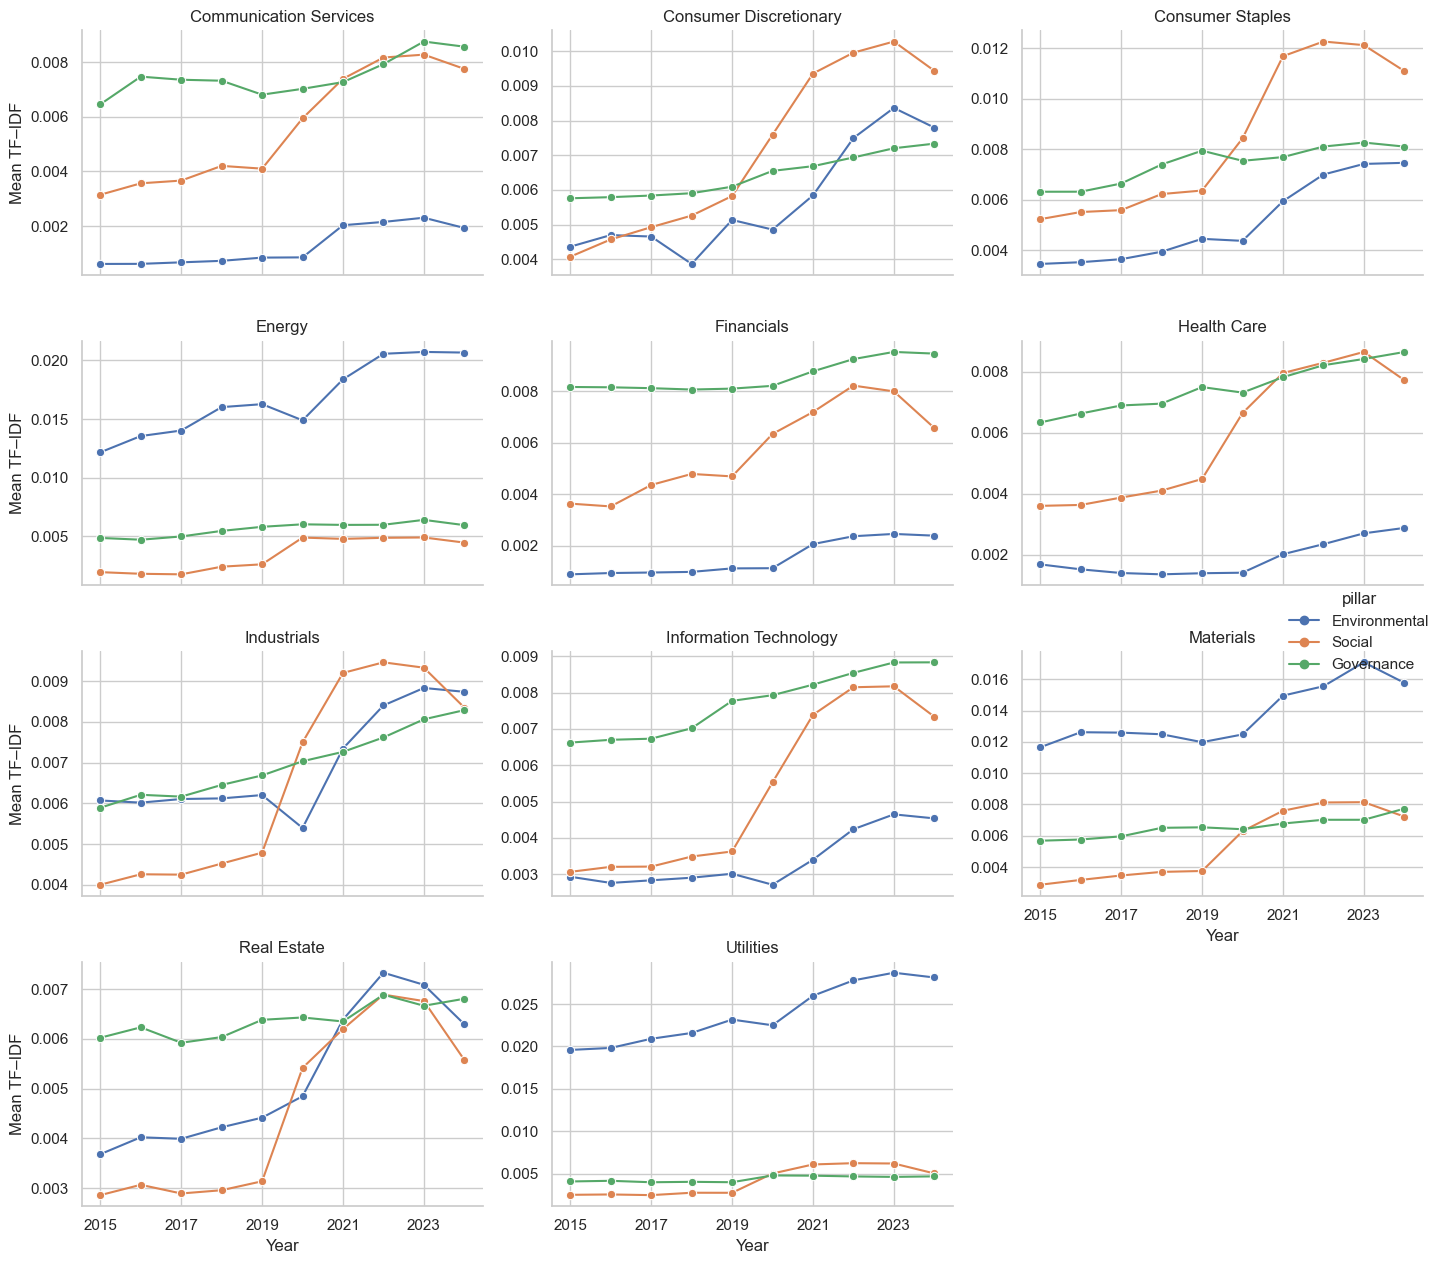

In [1]:
import math
import polars as pl
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------
# Config
# --------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "ESG_Lexicon.yml"
START_YEAR = 2015
END_YEAR = 2024

CHUNK_SIZE = 12          # smaller = lower RAM, slower
MIN_DOCS = 80            # "significant" GICS buckets (firm-year docs)
DF_CAP_SHARE = 0.98      # drop ultra-common terms (idf ~ 1, mostly boilerplate)

# --------------------
# Load lexicon (regex patterns)
# --------------------
with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

pillars = {
    "Environmental": list(lex.get("environmental") or []),
    "Social": list(lex.get("social") or []),
    "Governance": list(lex.get("governance") or []),
}

# Flatten term list with pillar labels
terms = []
for pillar, pats in pillars.items():
    for pat in pats:
        terms.append((pillar, pat))

# --------------------
# Build firm-year documents for whole S&P 500 universe
# --------------------
df = pl.read_parquet(
    PARQUET_FILE,
    columns=["cik", "gics_sector", "filing_period", "text"],
)

docs = (
    df.with_columns(
        pl.col("cik").cast(pl.Utf8),
        pl.col("gics_sector").cast(pl.Utf8),
        pl.col("filing_period").cast(pl.Date),
        pl.col("text").cast(pl.Utf8).fill_null(""),
        pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
    )
    .filter(
        pl.col("gics_sector").is_not_null()
        & pl.col("cik").is_not_null()
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
    )
    .group_by(["cik", "gics_sector", "year"])
    .agg(pl.col("text").str.concat("\n").alias("text"))
    .with_columns(pl.col("text").str.count_matches(r"(?i)\b\w+\b").alias("n_words"))
    .filter(pl.col("n_words") > 0)
)

N = int(docs.select(pl.len()).item())
if N == 0:
    raise RuntimeError("No firm-year documents found after filtering years/sector/cik.")

# Keep only "significant" GICS sectors (NO .collect() because docs is already a DataFrame)
sector_sizes = docs.group_by("gics_sector").agg(pl.len().alias("n_docs"))
keep_sectors = (
    sector_sizes.filter(pl.col("n_docs") >= MIN_DOCS)
                .get_column("gics_sector")
                .to_list()
)
docs = docs.filter(pl.col("gics_sector").is_in(keep_sectors))


N = int(docs.select(pl.len()).item())  # update N after dropping small sectors

# --------------------
# Compute pillar TF-IDF per firm-year (global IDF)
# --------------------
docs_work = docs.selectdocs_work = docs.select(["cik", "gics_sector", "year", "text", "n_words"]).with_columns(
    pl.lit(0.0).alias("tfidf_E"),
    pl.lit(0.0).alias("tfidf_S"),
    pl.lit(0.0).alias("tfidf_G"),
)

pillar_to_col = {
    "Environmental": "tfidf_E",
    "Social": "tfidf_S",
    "Governance": "tfidf_G",
}

for start in range(0, len(terms), CHUNK_SIZE):
    chunk = terms[start:start + CHUNK_SIZE]
    cnt_cols = [f"c{start+i:03d}" for i in range(len(chunk))]

    # count occurrences for this chunk
    tmp = docs_work.with_columns(
        [pl.col("text").str.count_matches(pat).alias(col) for (pillar, pat), col in zip(chunk, cnt_cols)]
    )

    # compute df and idf (global over all docs)
    idf_vals = []
    for col in cnt_cols:
        df_i = int(tmp.select((pl.col(col) > 0).sum()).item())
        if df_i / N >= DF_CAP_SHARE:
            idf_vals.append(0.0)
        else:
            idf_vals.append(math.log((N + 1) / (df_i + 1)) + 1.0)

    # accumulate TF-IDF into the correct pillar column
    expr_updates = {}
    for (pillar, _pat), col, idf in zip(chunk, cnt_cols, idf_vals):
        if idf == 0.0:
            continue
        tfidf_term = (pl.col(col).cast(pl.Float64) / pl.col("n_words").cast(pl.Float64)) * pl.lit(idf)
        target = pillar_to_col[pillar]
        expr_updates[target] = expr_updates.get(target, pl.lit(0.0)) + tfidf_term

    if expr_updates:
        tmp = tmp.with_columns([(pl.col(k) + v).alias(k) for k, v in expr_updates.items()])

    # drop chunk count columns and continue
    docs_work = tmp.drop(cnt_cols)

# --------------------
# Aggregate to sector-year mean pillar TF-IDF
# --------------------
sector_year = (
    docs_work.group_by(["gics_sector", "year"])
             .agg(
                 pl.mean("tfidf_E").alias("Environmental"),
                 pl.mean("tfidf_S").alias("Social"),
                 pl.mean("tfidf_G").alias("Governance"),
             )
             .sort(["gics_sector", "year"])
)

# Long format for seaborn
plot_df = (
    sector_year.unpivot(
        index=["gics_sector", "year"],
        on=["Environmental", "Social", "Governance"],
        variable_name="pillar",
        value_name="mean_tfidf",
    )
    .to_pandas()
)

# --------------------
# Plot: Facet grid (one panel per sector)
# --------------------
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=plot_df,
    x="year",
    y="mean_tfidf",
    hue="pillar",
    kind="line",
    col="gics_sector",
    col_wrap=3,            # grid width
    height=3.2,
    aspect=1.35,
    marker="o",
    facet_kws={"sharey": False},
)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Mean TF–IDF")
for ax in g.axes.flatten():
    ax.set_xticks(list(range(START_YEAR, END_YEAR + 1, 2)))  # lighter axis
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [9]:
import math
from pathlib import Path

import polars as pl
import yaml

# ----------------------------
# Inputs
# ----------------------------
PARQUET_FILE = "spy_10k_2015_present.parquet"
LEXICON_FILE = "ESG_Lexicon.yml"

ENV_TS_FILE = "environmental_time_series_01_01_2015_to_31_12_2024_rounded.csv"
GOV_TS_FILE = "governance_time_series_01_01_2015_to_31_12_2024.csv"

START_YEAR = 2015
END_YEAR = 2024

DF_CAP_SHARE = 0.98
CHUNK_SIZE = 12

OUT_DIR = Path("outputs") / "eg_scores_simple_by_year"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Helper: annualise trends -> year, pillar_mean
# ----------------------------
def annualise_trends(ts_path: str, out_col: str) -> pl.DataFrame:
    ts = pl.read_csv(ts_path)
    date_col = ts.columns[0]

    ts = ts.with_columns(
        pl.col(date_col).cast(pl.Utf8).str.strptime(pl.Date, strict=False).alias("date")
    )

    kw_cols = [c for c in ts.columns if c not in [date_col, "date"]]

    ts = ts.with_columns([pl.col(c).cast(pl.Float64) for c in kw_cols]).with_columns(
        pl.col("date").dt.year().alias("year")
    )

    annual = (
        ts.group_by("year")
          .agg([pl.mean(c).alias(c) for c in kw_cols])
          .sort("year")
          .with_columns(pl.mean_horizontal(kw_cols).alias(out_col))
          .select(["year", out_col])
          .sort("year")
    )
    return annual

# ----------------------------
# Trends weights: wE = E/(E+G), wG = G/(E+G)
# ----------------------------
e_tr = annualise_trends(ENV_TS_FILE, "E_mean")
g_tr = annualise_trends(GOV_TS_FILE, "G_mean")

den = (pl.col("E_mean") + pl.col("G_mean"))

year_w = (
    e_tr.join(g_tr, on="year", how="inner")
    .with_columns(
        pl.when(den > 0).then(pl.col("E_mean") / den).otherwise(0.5).alias("wE"),
        pl.when(den > 0).then(pl.col("G_mean") / den).otherwise(0.5).alias("wG"),
    )
    .select(["year", "wE", "wG"])
    .sort("year")
)

# ----------------------------
# Lexicon: E & G only
# ----------------------------
with open(LEXICON_FILE, "r", encoding="utf-8") as f:
    lex = yaml.safe_load(f)

pillars = {
    "E": list(lex.get("environmental") or []),
    "G": list(lex.get("governance") or []),
}

terms = [(p, pat) for p, pats in pillars.items() for pat in pats]
pillar_to_col = {"E": "tfidf_E", "G": "tfidf_G"}

# ----------------------------
# Load docs and compute firm-year TF-IDF (E, G)
# ----------------------------
df = pl.read_parquet(PARQUET_FILE)

# What this does: best-effort company name column selection
# Prefer a human-readable name if present; otherwise fall back to ticker; otherwise cik
# ----------------------------
# Load docs and compute firm-year TF-IDF (E, G)
# ----------------------------
df = pl.read_parquet(PARQUET_FILE)

# What this does: force ticker as the company identifier (fallback to cik)
if "ticker" in df.columns:
    label_expr = pl.col("ticker").cast(pl.Utf8).fill_null(pl.col("cik").cast(pl.Utf8)).alias("ticker")
else:
    label_expr = pl.col("cik").cast(pl.Utf8).alias("ticker")

docs = (
    df.with_columns(
        pl.col("cik").cast(pl.Utf8),
        pl.col("filing_period").cast(pl.Date),
        pl.col("text").cast(pl.Utf8).fill_null(""),
        pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
        label_expr,
    )
    .filter(
        pl.col("cik").is_not_null()
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
    )
    .group_by(["cik", "ticker", "year"])
    .agg(pl.col("text").str.concat("\n").alias("text"))
    .with_columns(pl.col("text").str.count_matches(r"(?i)\b\w+\b").alias("n_words"))
    .filter(pl.col("n_words") > 0)
)

N = int(docs.select(pl.len()).item())

docs_work = docs.select(["cik", "ticker", "year", "text", "n_words"]).with_columns(
    pl.lit(0.0).alias("tfidf_E"),
    pl.lit(0.0).alias("tfidf_G"),
)

# ... (your TF-IDF chunk loop unchanged) ...

firm_year = docs_work.select(["ticker", "year", "tfidf_E", "tfidf_G"])

# ... (your z-score block unchanged) ...

firm_year = (
    firm_year.join(year_w, on="year", how="left")
    .with_columns(
        pl.col("wE").fill_null(0.5),
        pl.col("wG").fill_null(0.5),
        (pl.col("wE") * pl.col("zE") + pl.col("wG") * pl.col("zG")).alias("score_raw"),
        (pl.col("score_raw").rank(method="average").over("year") / pl.len().over("year") * 100.0).alias("score"),
    )
)

# ----------------------------
# Write per-year CSVs with exactly 3 columns: year, ticker, score
# ----------------------------
simple = firm_year.select(["year", "ticker", "score"]).sort(["year", "score"], descending=[False, True])

for y in range(START_YEAR, END_YEAR + 1):
    simple.filter(pl.col("year") == y).write_csv(OUT_DIR / f"eg_scores_{y}.csv")

docs = (
    df.with_columns(
        pl.col("cik").cast(pl.Utf8),
        pl.col("filing_period").cast(pl.Date),
        pl.col("text").cast(pl.Utf8).fill_null(""),
        pl.col("filing_period").cast(pl.Date).dt.year().alias("year"),
        name_expr,
    )
    .filter(
        pl.col("cik").is_not_null()
        & (pl.col("year") >= START_YEAR)
        & (pl.col("year") <= END_YEAR)
    )
    .group_by(["cik", "company_name", "year"])
    .agg(pl.col("text").str.concat("\n").alias("text"))
    .with_columns(pl.col("text").str.count_matches(r"(?i)\b\w+\b").alias("n_words"))
    .filter(pl.col("n_words") > 0)
)

N = int(docs.select(pl.len()).item())

docs_work = docs.select(["cik", "company_name", "year", "text", "n_words"]).with_columns(
    pl.lit(0.0).alias("tfidf_E"),
    pl.lit(0.0).alias("tfidf_G"),
)

for start in range(0, len(terms), CHUNK_SIZE):
    chunk = terms[start:start + CHUNK_SIZE]
    cnt_cols = [f"c{start+i:03d}" for i in range(len(chunk))]

    tmp = docs_work.with_columns(
        [pl.col("text").str.count_matches(pat).alias(col) for (p, pat), col in zip(chunk, cnt_cols)]
    )

    idf_vals = []
    for col in cnt_cols:
        df_i = int(tmp.select((pl.col(col) > 0).sum()).item())
        if df_i / N >= DF_CAP_SHARE:
            idf_vals.append(0.0)
        else:
            idf_vals.append(math.log((N + 1) / (df_i + 1)) + 1.0)

    expr_updates = {}
    for (p, _), col, idf in zip(chunk, cnt_cols, idf_vals):
        if idf == 0.0:
            continue
        tfidf_term = (pl.col(col).cast(pl.Float64) / pl.col("n_words").cast(pl.Float64)) * pl.lit(idf)
        target = pillar_to_col[p]
        expr_updates[target] = expr_updates.get(target, pl.lit(0.0)) + tfidf_term

    if expr_updates:
        tmp = tmp.with_columns([(pl.col(k) + v).alias(k) for k, v in expr_updates.items()])

    docs_work = tmp.drop(cnt_cols)

firm_year = docs_work.select(["company_name", "year", "tfidf_E", "tfidf_G"])

# ----------------------------
# Mean TF-IDF standardisation within year (zE, zG)
# ----------------------------
firm_year = (
    firm_year.join(
        firm_year.group_by("year").agg(
            pl.mean("tfidf_E").alias("muE"), pl.std("tfidf_E").alias("sdE"),
            pl.mean("tfidf_G").alias("muG"), pl.std("tfidf_G").alias("sdG"),
        ),
        on="year",
        how="left",
    )
    .with_columns(
        ((pl.col("tfidf_E") - pl.col("muE")) / pl.col("sdE")).fill_nan(0.0).fill_null(0.0).alias("zE"),
        ((pl.col("tfidf_G") - pl.col("muG")) / pl.col("sdG")).fill_nan(0.0).fill_null(0.0).alias("zG"),
    )
    .drop(["muE", "sdE", "muG", "sdG"])
)

# ----------------------------
# Final E&G score: wE*zE + wG*zG (two-variable trends formula)
# ----------------------------
firm_year = (
    firm_year.join(year_w, on="year", how="left")
    .with_columns(
        pl.col("wE").fill_null(0.5),
        pl.col("wG").fill_null(0.5),
        (pl.col("wE") * pl.col("zE") + pl.col("wG") * pl.col("zG")).alias("score_raw"),
        (pl.col("score_raw").rank(method="average").over("year") / pl.len().over("year") * 100.0).alias("score"),
    )
)

# ----------------------------
# Write per-year CSVs with exactly 3 columns: year, company_name, score
# ----------------------------
simple = firm_year.select(["year", "company_name", "score"]).sort(["year", "score"], descending=[False, True])

for y in range(START_YEAR, END_YEAR + 1):
    simple.filter(pl.col("year") == y).write_csv(OUT_DIR / f"eg_scores_{y}.csv")

C:\Users\ddddd\AppData\Local\Temp\ipykernel_7072\1966835967.py:116: DeprecationWarning: `str.concat` is deprecated; use `str.join` instead. Note also that the default `delimiter` for `str.join` is an empty string, not a hyphen.
  .agg(pl.col("text").str.concat("\n").alias("text"))


ColumnNotFoundError: unable to find column "zE"; valid columns: ["ticker", "year", "tfidf_E", "tfidf_G", "wE", "wG"]

In [ ]:
import polars as pl
from pathlib import Path

# --------------------
# Hardcoded Annual Trends
# --------------------
df_trend = pl.DataFrame({
    "year": [
        2015,2016,2017,2018,2019,
        2020,2021,2022,2023,2024
    ],
    "trend_E": [
        14.854167,
        14.177083,
        13.010417,
        12.333333,
        11.5,
        10.34375,
        10.114583,
        13.052083,
        12.958333,
        14.635417
    ],
    "trend_G": [
        7.0,
        6.2,
        5.4,
        4.6,
        4.4,
        4.4,
        3.8,
        5.8,
        5.4,
        7.4
    ]
})

# --------------------
# Firm-Year ESG Scoring
# --------------------
df_scores = (
    docs_work
    .join(df_trend, on="year", how="left")
    .with_columns([
        (pl.col("tfidf_E") * pl.col("trend_E")).alias("esg_E_score"),
        (pl.col("tfidf_G") * pl.col("trend_G")).alias("esg_G_score")
    ])
    .select([
        "cik",
        "year",
        "esg_E_score",
        "esg_G_score"
    ])
    .sort(["year", "cik"])
)

df_scores_scaled = (
    df_scores
    .with_columns([
        (
            100 * (
                (pl.col("esg_E_score") - pl.col("esg_E_score").min().over("year")) /
                (pl.col("esg_E_score").max().over("year") - pl.col("esg_E_score").min().over("year"))
            )
        ).alias("esg_E_index"),

        (
            100 * (
                (pl.col("esg_G_score") - pl.col("esg_G_score").min().over("year")) /
                (pl.col("esg_G_score").max().over("year") - pl.col("esg_G_score").min().over("year"))
            )
        ).alias("esg_G_index")
    ])
    .select([
        "cik",
        "year",
        "esg_E_index",
        "esg_G_index"
    ])
    .sort(["year", "cik"])
)

df_scores_index = (
    df_scores
    .with_columns([
        (
            pl.col("esg_E_score")
            .rank("average")
            .over("year")
            / pl.count().over("year")
            * 100
        ).ceil().alias("E_score"),

        (
            pl.col("esg_G_score")
            .rank("average")
            .over("year")
            / pl.count().over("year")
            * 100
        ).ceil().alias("G_score")
    ])
    .select(["cik", "year", "E_score", "G_score"])
    .sort(["year", "cik"])
)

# --------------------
# Save CSV
# --------------------
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

out_path = OUT_DIR / "firm_year_esg_scores.csv"
df_scores.write_csv(out_path)

out_path = OUT_DIR / "firm_year_esg_scores.csv"
df_scores_index.write_csv(out_path)

print("Saved:", out_path)
print(df_scores_index.head(10))
print("Total rows:", df_scores_index.height)

Saved: outputs\firm_year_esg_scores.csv
shape: (10, 4)
┌────────────┬──────┬───────────┬───────────┐
│ cik        ┆ year ┆ E_score   ┆ G_score   │
│ ---        ┆ ---  ┆ ---       ┆ ---       │
│ str        ┆ i32  ┆ f64       ┆ f64       │
╞════════════╪══════╪═══════════╪═══════════╡
│ 0000001800 ┆ 2015 ┆ 56.650246 ┆ 32.758621 │
│ 0000002488 ┆ 2015 ┆ 70.197044 ┆ 23.891626 │
│ 0000002969 ┆ 2015 ┆ 89.901478 ┆ 88.916256 │
│ 0000004127 ┆ 2015 ┆ 73.399015 ┆ 44.334975 │
│ 0000004904 ┆ 2015 ┆ 96.79803  ┆ 5.91133   │
│ 0000004962 ┆ 2015 ┆ 11.330049 ┆ 91.133005 │
│ 0000004977 ┆ 2015 ┆ 11.82266  ┆ 21.674877 │
│ 0000005272 ┆ 2015 ┆ 38.423645 ┆ 36.945813 │
│ 0000006281 ┆ 2015 ┆ 67.980296 ┆ 36.206897 │
│ 0000006951 ┆ 2015 ┆ 88.669951 ┆ 23.399015 │
└────────────┴──────┴───────────┴───────────┘
Total rows: 4510


C:\Users\ddddd\AppData\Local\Temp\ipykernel_18036\3454667635.py:90: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  / pl.count().over("year")
C:\Users\ddddd\AppData\Local\Temp\ipykernel_18036\3454667635.py:98: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  / pl.count().over("year")


In [5]:
print(df_scores.head(20))

shape: (20, 11)
┌────────────┬────────────┬──────┬────────────┬───┬──────────┬───────────┬────────────┬────────────┐
│ cik        ┆ gics_secto ┆ year ┆ text       ┆ … ┆ tfidf_G  ┆ trend_E   ┆ esg_E_scor ┆ esg_G_scor │
│ ---        ┆ r          ┆ ---  ┆ ---        ┆   ┆ ---      ┆ ---       ┆ e          ┆ e          │
│ str        ┆ ---        ┆ i32  ┆ str        ┆   ┆ f64      ┆ f64       ┆ ---        ┆ ---        │
│            ┆ str        ┆      ┆            ┆   ┆          ┆           ┆ f64        ┆ f64        │
╞════════════╪════════════╪══════╪════════════╪═══╪══════════╪═══════════╪════════════╪════════════╡
│ 0000001800 ┆ Health     ┆ 2015 ┆ ITEM 1.    ┆ … ┆ 0.004748 ┆ 14.854167 ┆ 0.045947   ┆ 0.070531   │
│            ┆ Care       ┆      ┆ BUSINESS   ┆   ┆          ┆           ┆            ┆            │
│            ┆            ┆      ┆ GENERAL    ┆   ┆          ┆           ┆            ┆            │
│            ┆            ┆      ┆ DE…        ┆   ┆          ┆           ┆ 